# **PENGUMPULAN DATASET**

## **Mount Drive**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# **Load Dataset Path**

In [ ]:
DATA_PATH = "/content/drive/Shareddrives/PROJECT KA KEL 9/DataCoSupplyChainDataset.csv"

## **Read_csv**

In [ ]:
import pandas as pd

df = pd.read_csv(DATA_PATH, encoding='latin1')

# **EXPLORATORY DATA ANALYSIS (EDA)**

## **Missing Value**

In [ ]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


## **Struktur Dataset**

In [ ]:
print(df.shape)
df.head()

(180519, 53)


,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.75,0,1/15/2018 11:24,Standard Class


In [ ]:
print("Jumlah baris dan kolom :", df.shape)
print("\nTipe data tiap kolom :")
print(df.dtypes)

Jumlah baris dan kolom : (180519, 53)

Tipe data tiap kolom :
Type                              object
Days for shipping (real)           int64
Days for shipment (scheduled)      int64
Benefit per order                float64
Sales per customer               float64
Delivery Status                   object
Late_delivery_risk                 int64
Category Id                        int64
Category Name                     object
Customer City                     object
Customer Country                  object
Customer Email                    object
Customer Fname                    object
Customer Id                        int64
Customer Lname                    object
Customer Password                 object
Customer Segment                  object
Customer State                    object
Customer Street                   object
Customer Zipcode                 float64
Department Id                      int64
Department Name                   object
Latitude                         flo

## **Variabel Target**

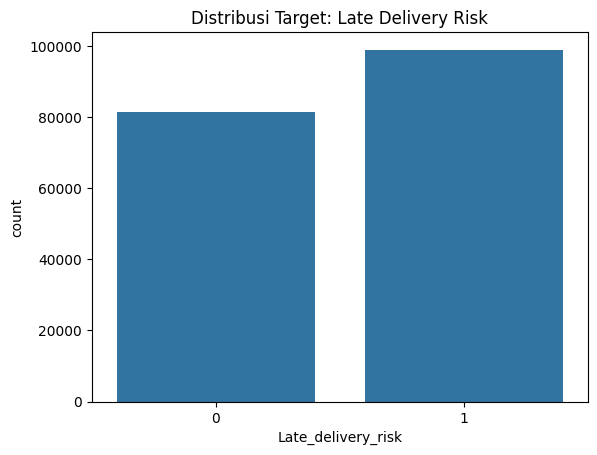

,proportion
Late_delivery_risk,
1,0.548291
0,0.451709


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x=df['Late_delivery_risk'])
plt.title("Distribusi Target: Late Delivery Risk")
plt.show()

df['Late_delivery_risk'].value_counts(normalize=True)

##**Fitur Waktu**

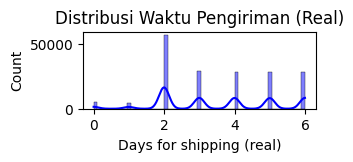

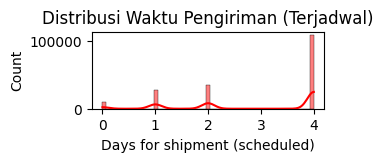

In [ ]:
plt.figure(figsize=(3,1))
sns.histplot(df['Days for shipping (real)'], kde=True, color='blue')
plt.title("Distribusi Waktu Pengiriman (Real)")
plt.show()
plt.figure(figsize=(3,1))
sns.histplot(df['Days for shipment (scheduled)'], kde=True, color='red')
plt.title("Distribusi Waktu Pengiriman (Terjadwal)")
plt.show()

## **Fitur Logistik**

### **Distribusi Durasi Pengiriman (Real) per Risiko**

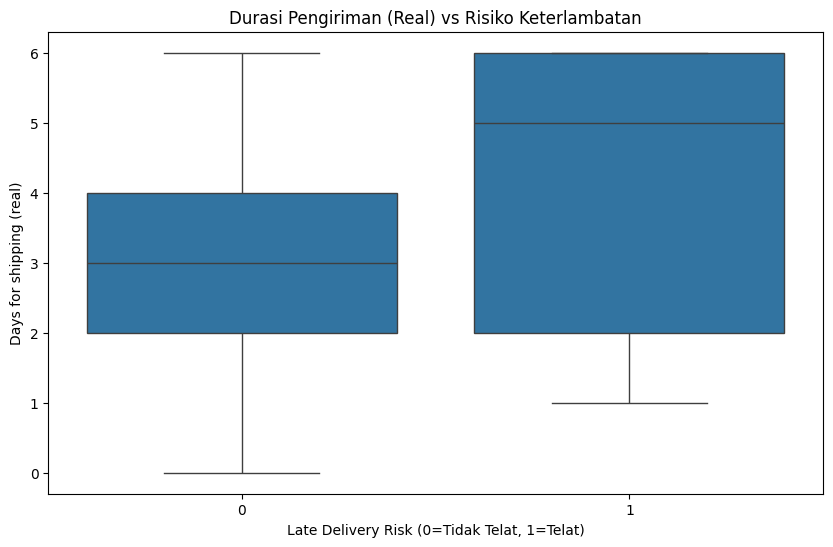

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(x=df["Late_delivery_risk"], y=df["Days for shipping (real)"])
plt.title("Durasi Pengiriman (Real) vs Risiko Keterlambatan")
plt.xlabel("Late Delivery Risk (0=Tidak Telat, 1=Telat)")
plt.ylabel("Days for shipping (real)")
plt.show()

### **Selisih Waktu Real vs Scheduled**

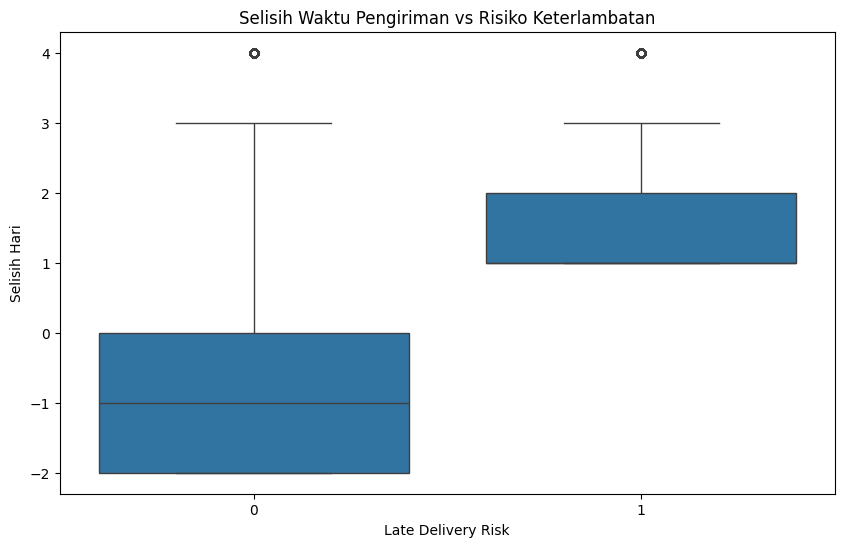

In [ ]:
df["Time_Difference"] = df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]

plt.figure(figsize=(10,6))
sns.boxplot(x=df["Late_delivery_risk"], y=df["Time_Difference"])
plt.title("Selisih Waktu Pengiriman vs Risiko Keterlambatan")
plt.xlabel("Late Delivery Risk")
plt.ylabel("Selisih Hari")
plt.show()

### **Analisis Per Region**

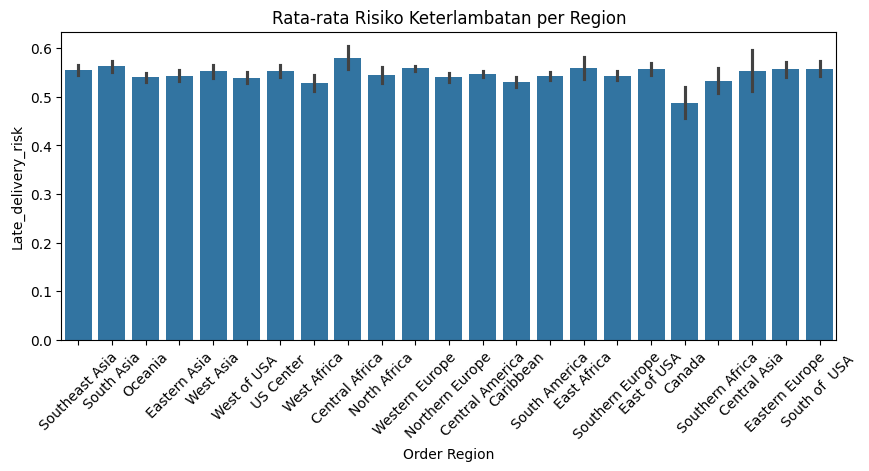

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(x=df["Order Region"], y=df["Late_delivery_risk"])
plt.title("Rata-rata Risiko Keterlambatan per Region")
plt.xticks(rotation=45)
plt.show()

### **Analisis Per Route (Order City → Customer City)**

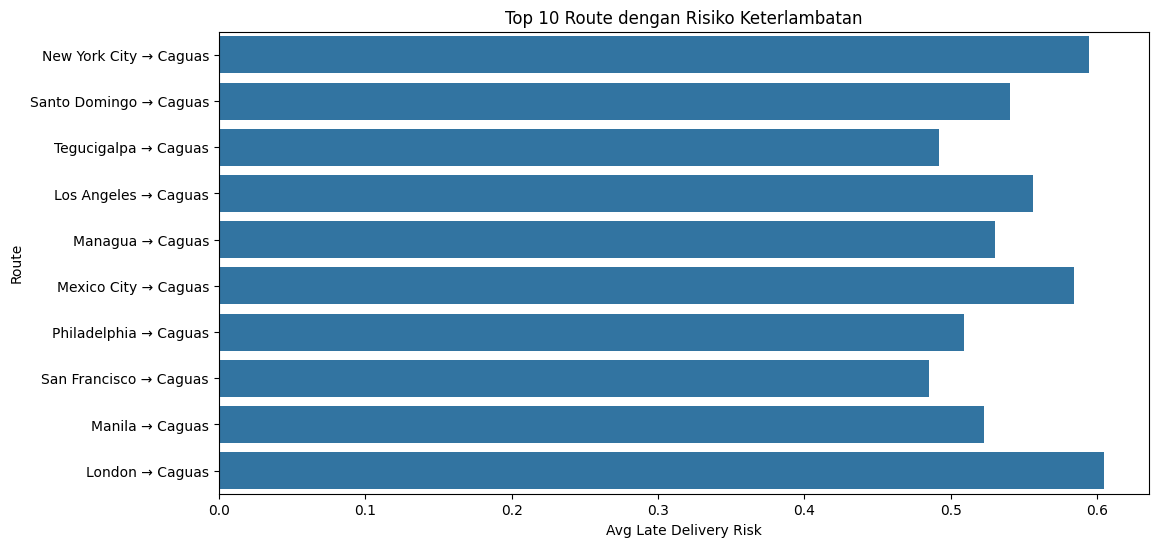

In [ ]:
df["Route"] = df["Order City"].astype(str) + " → " + df["Customer City"].astype(str)

top_routes = df["Route"].value_counts().head(10).index

plt.figure(figsize=(12,6))
sns.barplot(
    y=top_routes,
    x=[df[df["Route"] == r]["Late_delivery_risk"].mean() for r in top_routes]
)
plt.title("Top 10 Route dengan Risiko Keterlambatan")
plt.xlabel("Avg Late Delivery Risk")
plt.ylabel("Route")
plt.show()

## **Fitur Pelanggan & Produk**

### **10 Kota Pelanggan Terbanyak**

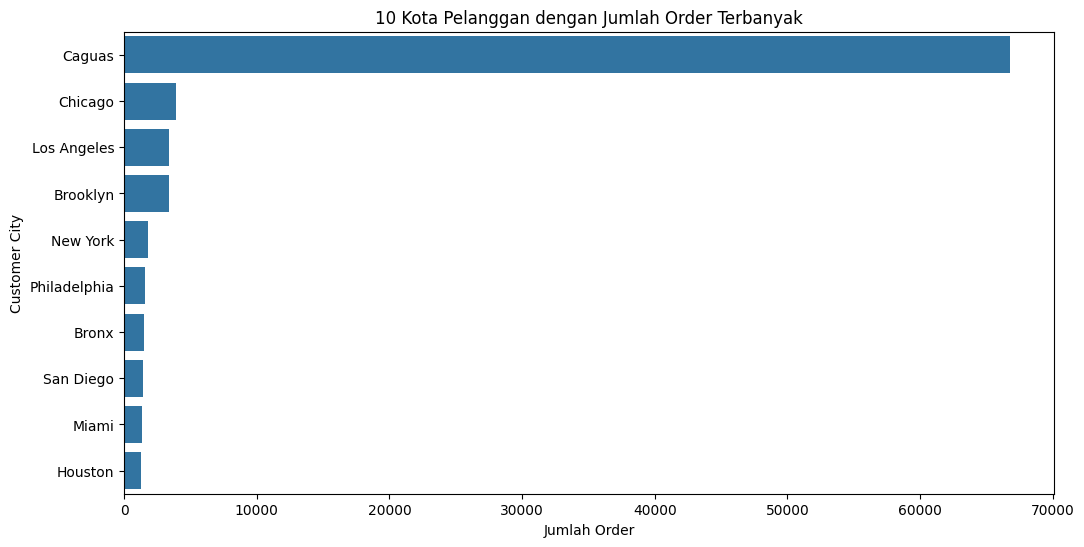

In [ ]:
top_city = df["Customer City"].value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_city.values, y=top_city.index)
plt.title("10 Kota Pelanggan dengan Jumlah Order Terbanyak")
plt.xlabel("Jumlah Order")
plt.ylabel("Customer City")
plt.show()

### **Durasi Pengiriman per Kategori Produk**


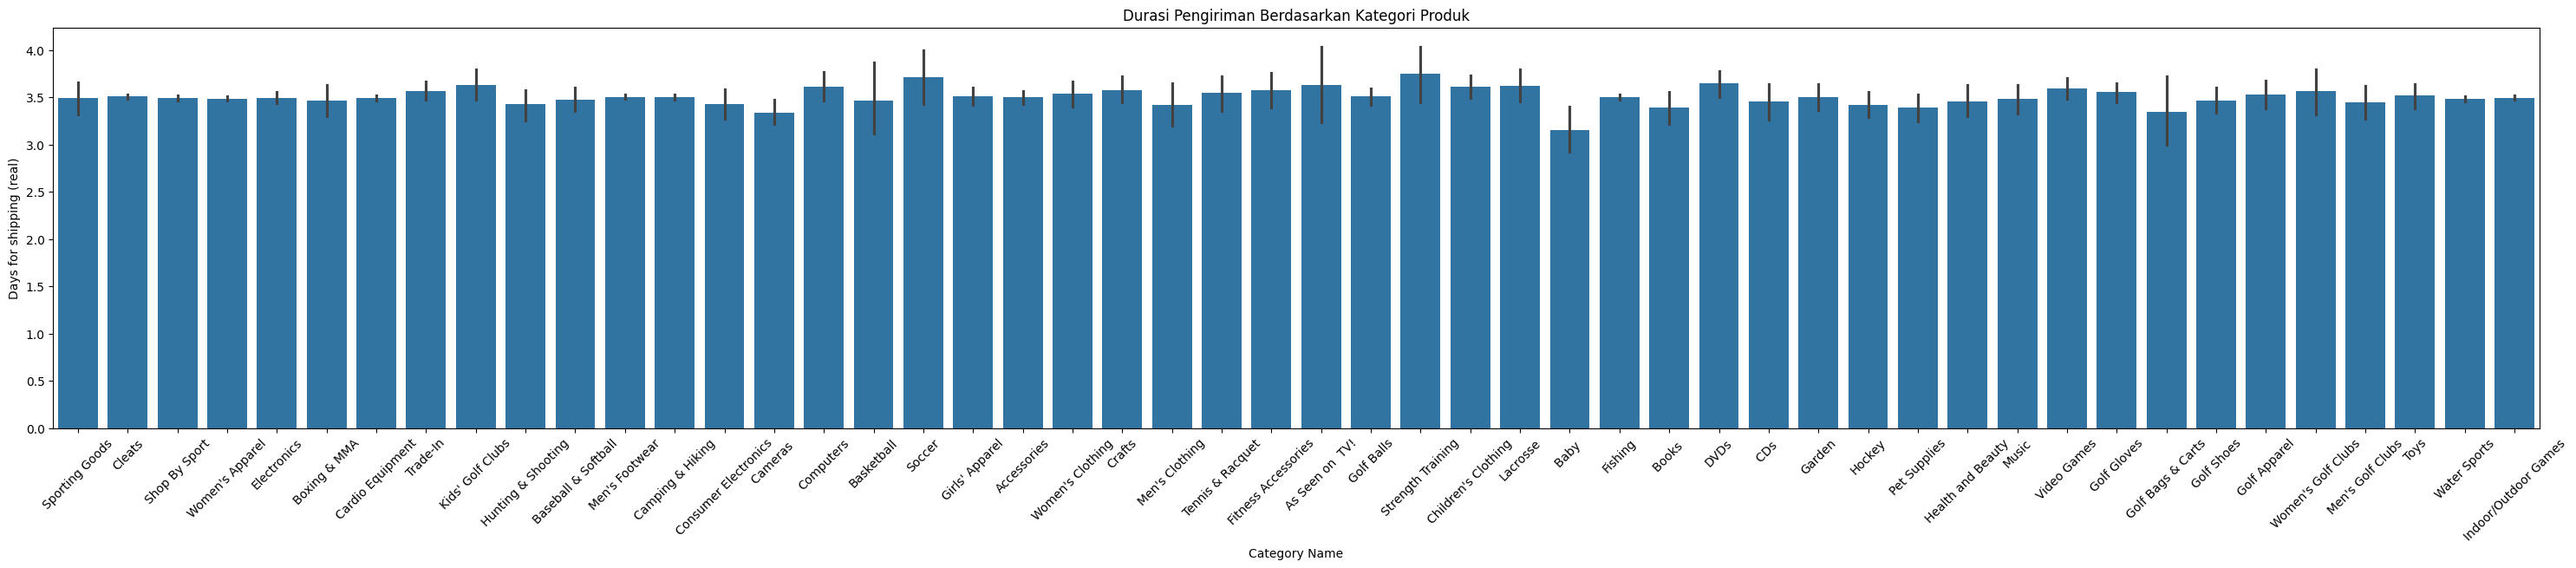

In [ ]:
plt.figure(figsize=(37,6))
sns.barplot(x=df["Category Name"], y=df["Days for shipping (real)"])
plt.title("Durasi Pengiriman Berdasarkan Kategori Produk")
plt.xticks(rotation=45)
plt.show()

## **Korelasi & Feature**

### **Korelasi Fitur Numerik (Heatmap Besar)**

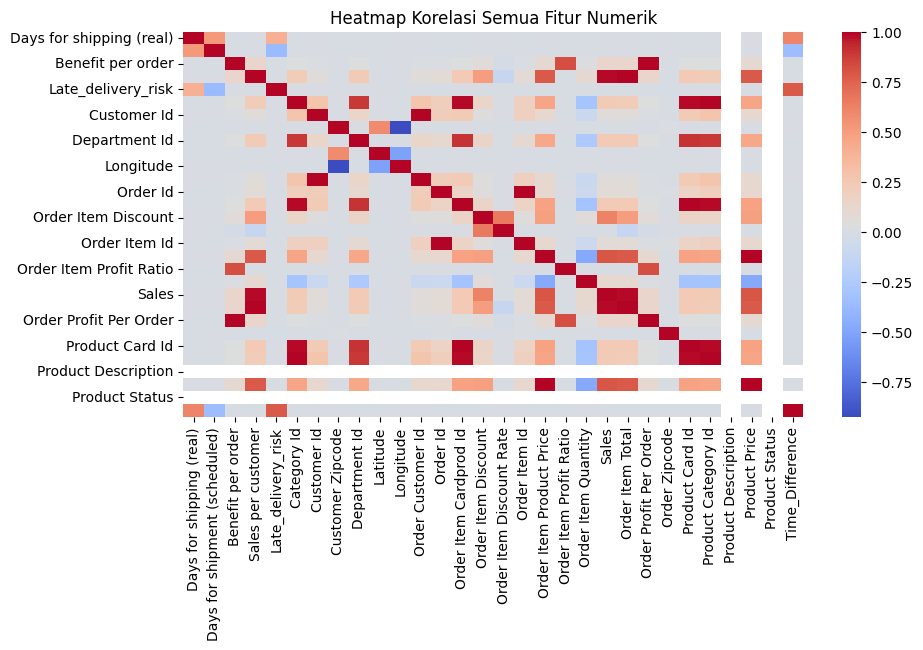

In [ ]:
numeric_df = df.select_dtypes(include=['int64','float64'])

plt.figure(figsize=(10,5))
sns.heatmap(numeric_df.corr(), cmap='coolwarm', annot=False)
plt.title("Heatmap Korelasi Semua Fitur Numerik")
plt.show()

### **Korelasi Fitur Logistik**

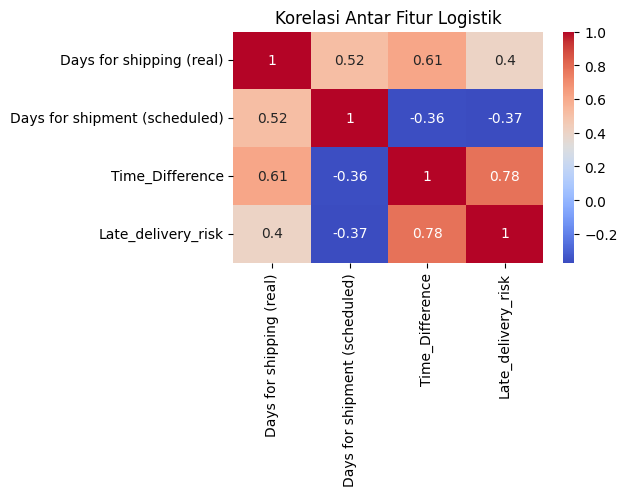

In [ ]:
log_cols = [
    "Days for shipping (real)",
    "Days for shipment (scheduled)",
    "Time_Difference",
    "Late_delivery_risk"
]

plt.figure(figsize=(5,3))
sns.heatmap(df[log_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Korelasi Antar Fitur Logistik")
plt.show()

### **Pair Plot**

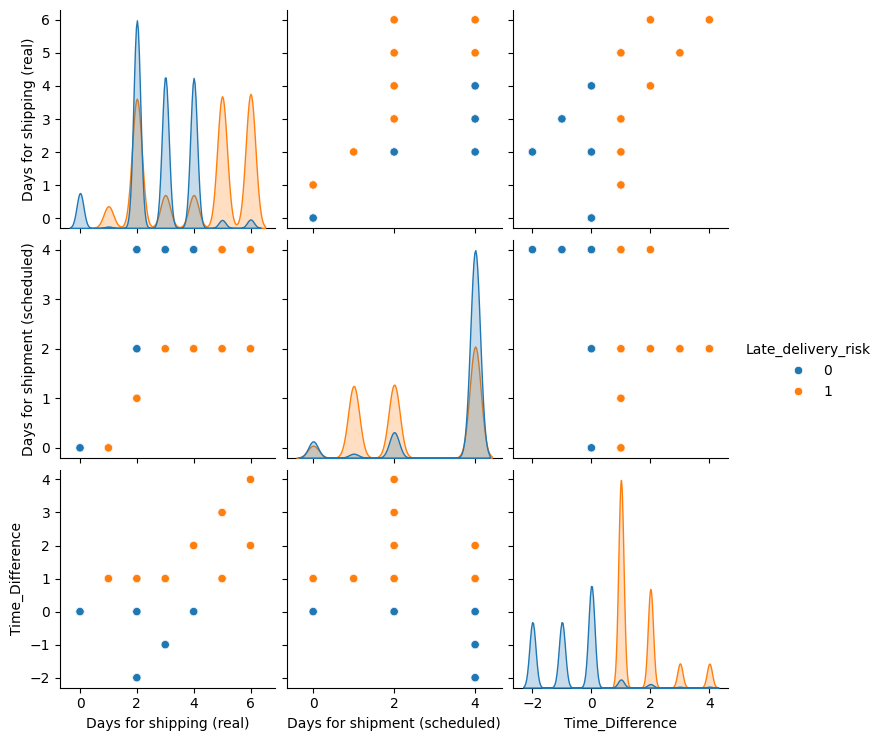

In [ ]:
sns.pairplot(df[["Days for shipping (real)", "Days for shipment (scheduled)", "Time_Difference", "Late_delivery_risk"]], hue="Late_delivery_risk")
plt.show()

# **DATA PREPROCESSING**

## **Cleaning**

### **Cek Missing**

In [ ]:
df.isnull().sum()

,0
Type,0
Days for shipping (real),0
Days for shipment (scheduled),0
Benefit per order,0
Sales per customer,0
Delivery Status,0
Late_delivery_risk,0
Category Id,0
Category Name,0
Customer City,0


### **drop dulicates & dropna**

In [ ]:
df.drop_duplicates()

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode,Time_Difference,Route
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class,-1,Bekasi → Caguas
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class,1,Bikaner → Caguas
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class,0,Bikaner → San Jose
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class,-1,Townsville → Los Angeles
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class,-2,Townsville → Caguas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class,0,Shanghái → Brooklyn
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class,1,Hirakata → Bakersfield
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class,1,Adelaide → Bristol
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class,-1,Adelaide → Caguas


### **Drop Sensitive Columns**

In [ ]:
drop_sensitive = [
    'Customer Email', 'Customer Password',
    'Customer Fname', 'Customer Lname',
    'Customer Street', 'Customer State',
    'Customer Zipcode', 'Order Zipcode'
]

df = df.drop(columns=[c for c in drop_sensitive if c in df.columns], errors='ignore')

### **Drop NA Target**

In [ ]:
df = df.dropna(subset=['Late_delivery_risk'])

### **Handling Missing Value (numeric → median)**

In [ ]:
for col in df.select_dtypes(include=['float64','int64']).columns:
    df[col] = df[col].fillna(df[col].median())

### **Handling Missing Value (categorical → "unknown")**

In [ ]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna("unknown")

print("CLEANING SELESAI ✔")
print(df.shape)

CLEANING SELESAI ✔
(180519, 47)


## **Encoding dan Scalling**

### **Pilih Kolom & Bikin df_model**

In [ ]:
selected_cols = [
    'Type',
    'Days for shipping (real)',
    'Days for shipment (scheduled)',
    'Benefit per order',
    'Sales per customer',
    'Order Item Quantity',
    'Order Item Discount',
    'Order Item Discount Rate',
    'Order Item Product Price',
    'Order Item Profit Ratio',
    'Customer City',
    'Customer Country',
    'Order Region',
    'Order State',
    'Order Status',
    'Late_delivery_risk'
]

df_model = df[selected_cols].copy()

### **Definisikan X dan y**

In [ ]:
y = df_model['Late_delivery_risk']
X = df_model.drop('Late_delivery_risk', axis=1)

## **Pisahkan Numerik & Kategorikal**

In [ ]:
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

print("Numerik :", num_features)
print("Kategori:", cat_features)

Numerik : ['Days for shipping (real)', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Order Item Quantity', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Item Profit Ratio']
Kategori: ['Type', 'Customer City', 'Customer Country', 'Order Region', 'Order State', 'Order Status']


## **Encoding(OneHotEncode)**

In [ ]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

categorical_transformer = Pipeline(steps=[
    ("imputer_cat", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

### **Scalling**

In [ ]:
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer_num", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

### **Gabungan Encoding + Scalling (ColumnsTrnasformer)**

In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features)
    ]
)

# **FEATURE ENGINEERING**

### **Time Difference**

In [ ]:
df["Time_Difference"] = (
    df["Days for shipping (real)"] - df["Days for shipment (scheduled)"]
)

### **Profit Margin**

In [ ]:
df["Profit_Margin"] = (
    df["Order Item Profit Ratio"] * df["Order Item Product Price"]
)

### **Region Code**

In [ ]:
df["Region_Code"] = df["Order Region"].astype('category').cat.codes

### **Route**

In [ ]:
df["Route"] = df["Order City"].astype(str) + " → " + df["Customer City"].astype(str)

### **Order Hour**

In [ ]:
df["OrderDate"] = pd.to_datetime(df["order date (DateOrders)"], errors="coerce")
df["Order_Hour"] = df["OrderDate"].dt.hour

### **Order Day of Week**

In [ ]:
df["Order_DayOfWeek"] = df["OrderDate"].dt.dayofweek

# **PEMODELAN MACHINE LEARNING**

## **Train Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### **Training Moden - Random Forest**

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("clf", RandomForestClassifier(
        n_estimators=200,
        max_depth=None,
        random_state=42
    ))
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer_num',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Days for shipping (real)',
                                                   'Days for shipment '
                                                   '(scheduled)',
                                                   'Benefit per order',
                                                   'Sales per customer',
                                                   'Order Item Quantity',
                                                   'Order Item Discount',
                                                   'Order Item Discount Rate',
                                                   'Order Item Product Price',
                                                   'Order Item Profit Ratio']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer_cat',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Type', 'Customer City',
                                                   'Customer Country',
                                                   'Order Region',
                                                   'Order State',
                                                   'Order Status'])])),
                ('clf',
                 RandomForestClassifier(n_estimators=200, random_state=42))])

## **Evaluasi Model**

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("=== HASIL EVALUASI MODEL RANDOM FOREST ===")
print("Accuracy :", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, zero_division=0))

=== HASIL EVALUASI MODEL RANDOM FOREST ===
Accuracy : 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     16308
           1       1.00      1.00      1.00     19796

    accuracy                           1.00     36104
   macro avg       1.00      1.00      1.00     36104
weighted avg       1.00      1.00      1.00     36104



## **Confusion Matrix**

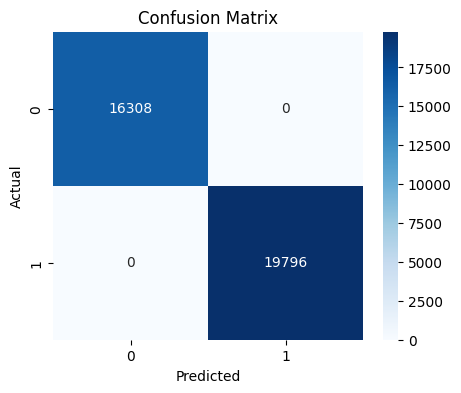

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# **INTERPRETASI DAN INSIGHT**

## **Insight Keterlambatan**

### **INSIGHT 1 — Rata-rata Selisih Waktu (Time Difference)**

In [ ]:
df.groupby("Late_delivery_risk")["Time_Difference"].mean()

,Time_Difference
Late_delivery_risk,
0,-0.711584
1,1.618184


### **INSIGHT 2 — Risiko Telat per Region**

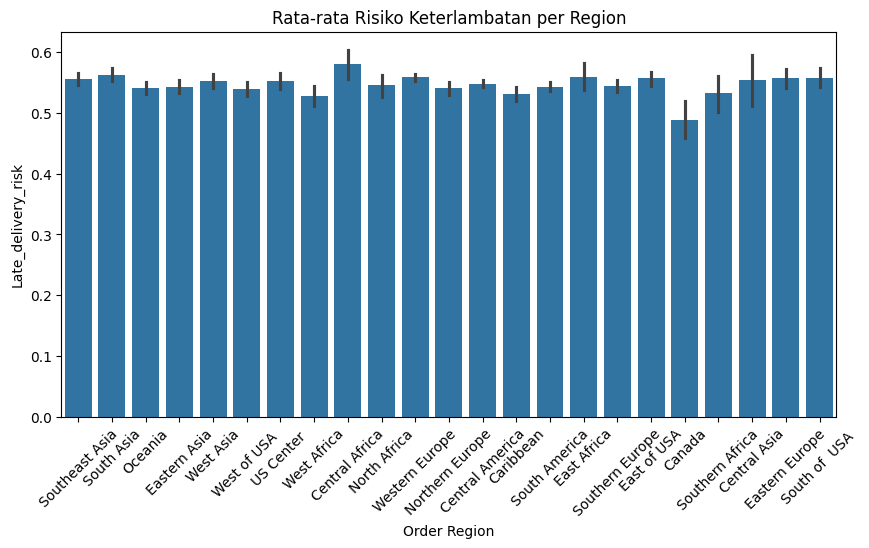

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=df["Order Region"], y=df["Late_delivery_risk"])
plt.title("Rata-rata Risiko Keterlambatan per Region")
plt.xticks(rotation=45)
plt.show()

### **INSIGHT 3 — Risiko Telat per Shipping Mode**

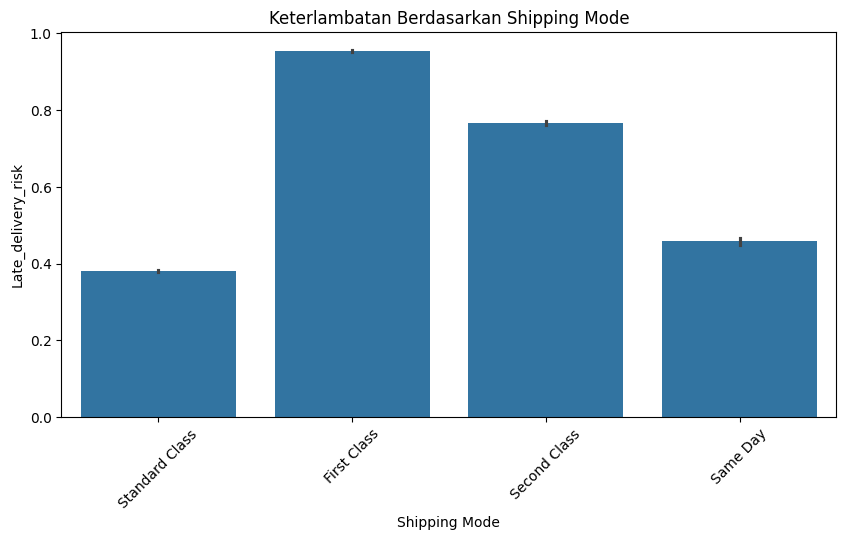

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x=df["Shipping Mode"], y=df["Late_delivery_risk"])
plt.title("Keterlambatan Berdasarkan Shipping Mode")
plt.xticks(rotation=45)
plt.show()

### **INSIGHT 4 — Produk yang paling sering telat (Kategori)**

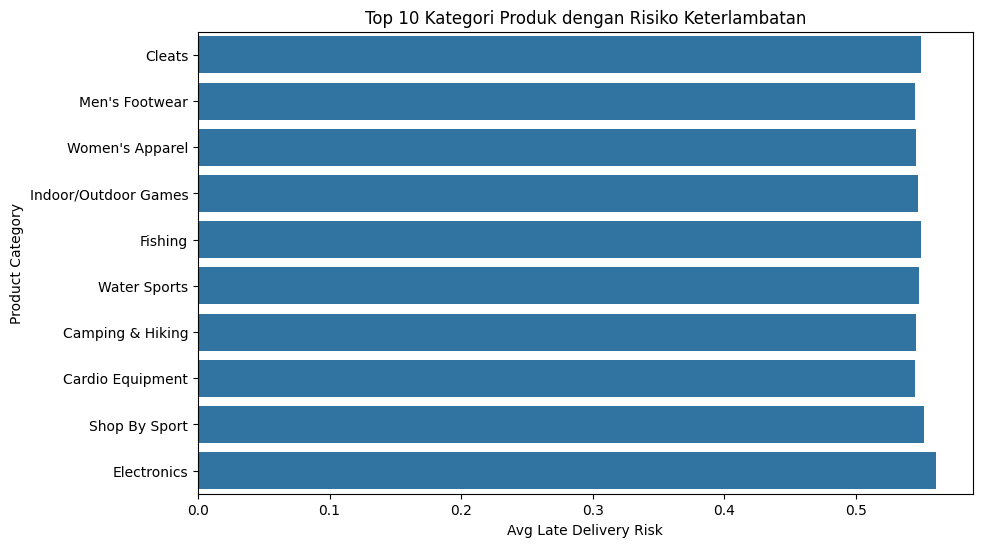

In [ ]:
top_cat = df["Category Name"].value_counts().head(10).index

plt.figure(figsize=(10,6))
sns.barplot(
    y=top_cat,
    x=[df[df["Category Name"]==c]["Late_delivery_risk"].mean() for c in top_cat]
)
plt.title("Top 10 Kategori Produk dengan Risiko Keterlambatan")
plt.xlabel("Avg Late Delivery Risk")
plt.ylabel("Product Category")
plt.show()

### **INSIGHT 5 — Route (Jalur) dengan risiko tertinggi**

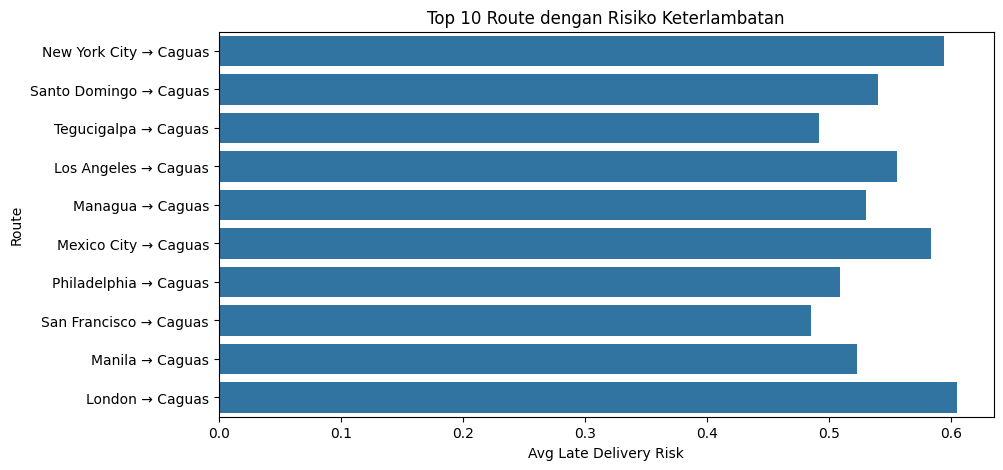

In [ ]:
df["Route"] = df["Order City"].astype(str) + " → " + df["Customer City"].astype(str)

top_routes = df["Route"].value_counts().head(10).index

plt.figure(figsize=(10,5))
sns.barplot(
    y=top_routes,
    x=[df[df["Route"] == r]["Late_delivery_risk"].mean() for r in top_routes]
)
plt.title("Top 10 Route dengan Risiko Keterlambatan")
plt.xlabel("Avg Late Delivery Risk")
plt.ylabel("Route")
plt.show()

### **INSIGHT 6 — Jam Order & Risiko Telat**

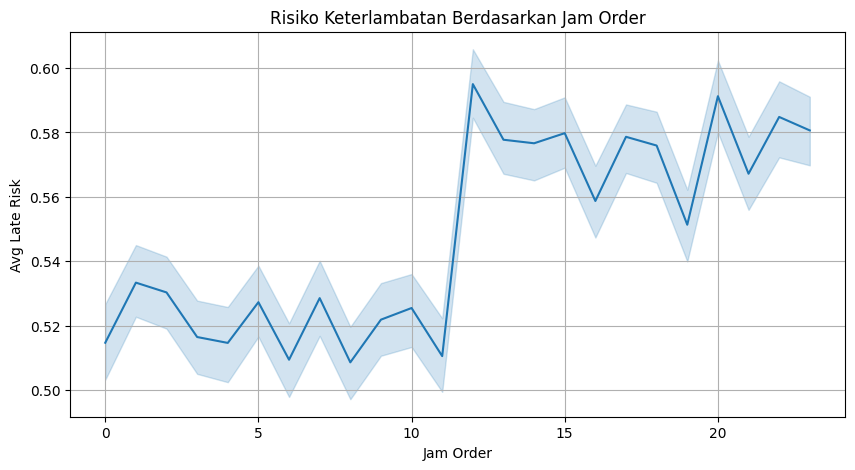

In [ ]:
df["OrderDate"] = pd.to_datetime(df["order date (DateOrders)"], errors='coerce')
df["Order_Hour"] = df["OrderDate"].dt.hour

plt.figure(figsize=(10,5))
sns.lineplot(x=df["Order_Hour"], y=df["Late_delivery_risk"])
plt.title("Risiko Keterlambatan Berdasarkan Jam Order")
plt.xlabel("Jam Order")
plt.ylabel("Avg Late Risk")
plt.grid(True)
plt.show()

### **INSIGHT 7 — Hari dalam Seminggu**

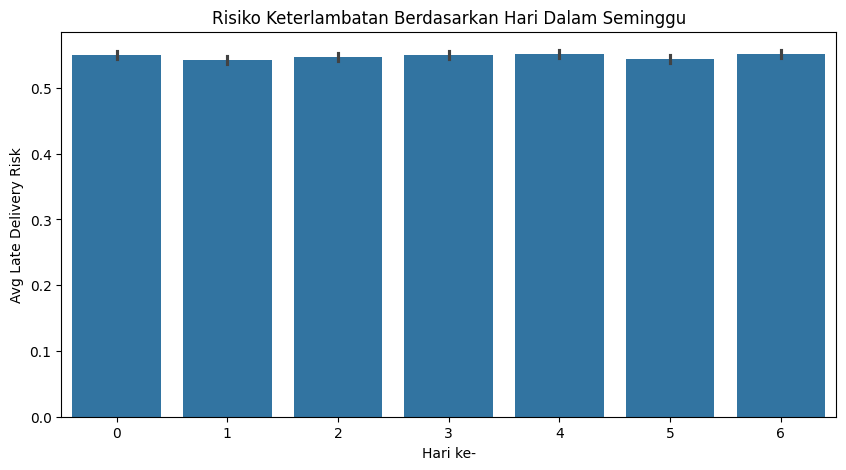

In [ ]:
df["Order_DayOfWeek"] = df["OrderDate"].dt.dayofweek

plt.figure(figsize=(10,5))
sns.barplot(x=df["Order_DayOfWeek"], y=df["Late_delivery_risk"])
plt.title("Risiko Keterlambatan Berdasarkan Hari Dalam Seminggu")
plt.xlabel("Hari ke-")
plt.ylabel("Avg Late Delivery Risk")
plt.show()

## **Feature Importance**

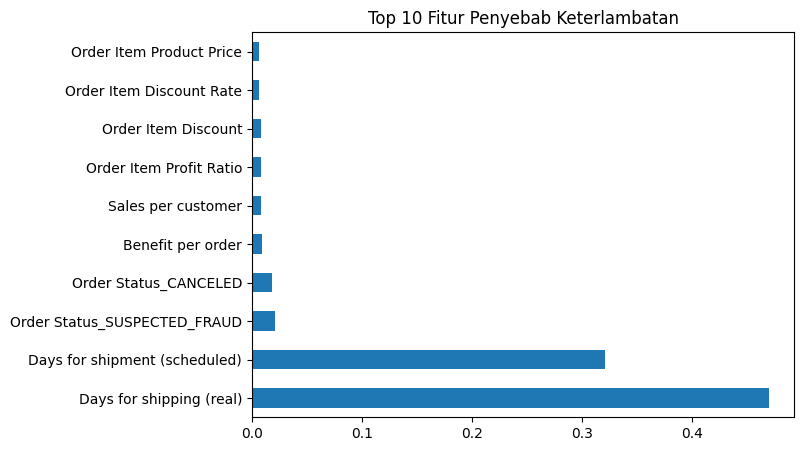

In [ ]:
ohe = model.named_steps["preprocessor"].named_transformers_["cat"].named_steps["onehot"]
ohe_features = list(ohe.get_feature_names_out(cat_features))
feature_names = num_features + ohe_features

importances = model.named_steps['clf'].feature_importances_

feat_imp = pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10)
feat_imp.plot(kind='barh', figsize=(7,5))
plt.title("Top 10 Fitur Penyebab Keterlambatan")
plt.show()